# Spring 2025 Final Project

You are tasked to identify employees who are expected to leave from the company. You are given the past data but unfortunately it does not have the labels. 

But John who has been here for a long long time can help you out. You can ask him for a limited number of times. 

__NOTE:__ Do NOT use this notebook as your project template. You can copy & paste items such as the class below into your notebook.


__Data:__

`https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/final/employee_departure_dataset_X.csv` 


Create your solution as a notebook and save your final model.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

In [2]:
import pandas as pd

class SME():
    
    def __init__(self):
        self.asked = 0
        self.df = self.get()
        
    def get(self):
        X_train = pd.read_csv('https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/final/employee_departure_dataset_X.csv')
        y_train = pd.read_csv('https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/final/employee_departure_dataset_y.csv')

        X_train['Left'] = y_train
        return X_train
    
    def ask(self, valuedict):
        self.asked += 1
        #  print(self.asked)
        
        if self.asked > 500:
            raise Exception("Sorry, you have asked enough")

        arr = []
        for prop in valuedict:
            val = valuedict[prop]

            if val is None: 
                continue

            val = f"'{val}'" if isinstance(val,str) else val
            # print(prop, val)
            arr.append(f'{prop} == {val}')

            query = ' and '.join(arr)
        result = self.df.query(query)

        if len(result) == 0:
            raise Exception("I don't know")
        
        return (int)(result['Left'].mean())

In [3]:
sme = SME()

In [4]:
sme.df.head()

,RecordId,Gender,Distance,YearsWorked,TrainingHours,WorkLifeBalance,NumOfProjects,JobInvolvement,TeamSize,MentorshipReceived,...,WorkSatisfactionScore,JobEngagementScore,PhysicalActivityScore,MentalWellbeingScore,DepartmentCode,PreviousSalary,Salary,SelfReview,SupervisorReview,Left
0,100,1,>30miles,7,91,4,14,3,8,1,...,3,2,9,5,5,72K,73K,4.0,4.0,0
1,101,0,~10miles,10,52,5,9,2,10,0,...,3,4,8,1,1,62K,64K,4.0,4.0,0
2,102,0,~10miles,10,80,3,13,3,16,0,...,7,2,7,8,5,73K,74K,4.0,2.0,1
3,103,0,~15miles,5,6,3,15,5,16,0,...,6,9,5,5,1,63K,64K,5.0,5.0,0
4,104,1,~10miles,10,3,2,13,3,18,0,...,3,4,4,4,2,60K,64K,4.0,4.0,0


You can ask the expert for the label.

If he doesn't know the answer, he will freak out so ask only from the training set 
but do not ask him for every data point

In [5]:
# e.g.
sme.ask({
    'RecordId': 101,   
})

0

In [6]:
sme.ask({
    'YearsWorked': 7,
    'NumOfProjects': 14,
    'JobInvolvement': 3,
    'Distance': '~10miles'
})

0

## EDA

In [7]:
df = pd.read_csv('https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/final/employee_departure_dataset_X.csv')

In [8]:
df.shape

(500000, 27)

In [9]:
df.head()

,RecordId,Gender,Distance,YearsWorked,TrainingHours,WorkLifeBalance,NumOfProjects,JobInvolvement,TeamSize,MentorshipReceived,...,ProjectComplexity,WorkSatisfactionScore,JobEngagementScore,PhysicalActivityScore,MentalWellbeingScore,DepartmentCode,PreviousSalary,Salary,SelfReview,SupervisorReview
0,100,1,>30miles,7,91,4,14,3,8,1,...,2,3,2,9,5,5,72K,73K,4.0,4.0
1,101,0,~10miles,10,52,5,9,2,10,0,...,1,3,4,8,1,1,62K,64K,4.0,4.0
2,102,0,~10miles,10,80,3,13,3,16,0,...,3,7,2,7,8,5,73K,74K,4.0,2.0
3,103,0,~15miles,5,6,3,15,5,16,0,...,4,6,9,5,5,1,63K,64K,5.0,5.0
4,104,1,~10miles,10,3,2,13,3,18,0,...,3,3,4,4,4,2,60K,64K,4.0,4.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 27 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   RecordId                 500000 non-null  int64  
 1   Gender                   500000 non-null  int64  
 2   Distance                 499492 non-null  object 
 3   YearsWorked              500000 non-null  int64  
 4   TrainingHours            500000 non-null  int64  
 5   WorkLifeBalance          500000 non-null  int64  
 6   NumOfProjects            500000 non-null  int64  
 7   JobInvolvement           500000 non-null  int64  
 8   TeamSize                 500000 non-null  int64  
 9   MentorshipReceived       500000 non-null  int64  
 10  TechSkillLevel           500000 non-null  int64  
 11  AttendanceRate           500000 non-null  float64
 12  StressLevel              500000 non-null  int64  
 13  PeerFeedbackScore        500000 non-null  int64  
 14  Annu

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RecordId,500000.0,250099.500000,144337.711634,100.000000,125099.750000,250099.500000,375099.250000,500099.000000
Gender,500000.0,0.401232,0.490148,0.000000,0.000000,0.000000,1.000000,1.000000
YearsWorked,500000.0,7.002552,1.868050,0.000000,6.000000,7.000000,8.000000,14.000000
TrainingHours,500000.0,49.483502,28.866048,0.000000,24.000000,50.000000,74.000000,99.000000
WorkLifeBalance,500000.0,3.002836,1.413991,1.000000,2.000000,3.000000,4.000000,5.000000
NumOfProjects,500000.0,10.007036,5.478671,1.000000,5.000000,10.000000,15.000000,19.000000
JobInvolvement,500000.0,2.996948,1.414536,1.000000,2.000000,3.000000,4.000000,5.000000
TeamSize,500000.0,9.998880,5.479373,1.000000,5.000000,10.000000,15.000000,19.000000
MentorshipReceived,500000.0,0.500670,0.500000,0.000000,0.000000,1.000000,1.000000,1.000000
TechSkillLevel,500000.0,2.999154,1.414082,1.000000,2.000000,3.000000,4.000000,5.000000


In [12]:
df.isnull().sum()

RecordId                      0
Gender                        0
Distance                    508
YearsWorked                   0
TrainingHours                 0
WorkLifeBalance               0
NumOfProjects                 0
JobInvolvement                0
TeamSize                      0
MentorshipReceived            0
TechSkillLevel                0
AttendanceRate                0
StressLevel                   0
PeerFeedbackScore             0
AnnualLeaveDays               0
Certifications                0
SkillDevelopmentCourses       0
ProjectComplexity             0
WorkSatisfactionScore         0
JobEngagementScore            0
PhysicalActivityScore         0
MentalWellbeingScore          0
DepartmentCode                0
PreviousSalary                0
Salary                        0
SelfReview                 1042
SupervisorReview            995
dtype: int64

In [13]:
for i in df.columns:
    print(f"\n count for column: {i}")
    print(df[i].value_counts(dropna=False))


 count for column: RecordId
RecordId
100       1
333443    1
333441    1
333440    1
333439    1
         ..
166762    1
166761    1
166760    1
166759    1
500099    1
Name: count, Length: 500000, dtype: int64

 count for column: Gender
Gender
0    299384
1    200616
Name: count, dtype: int64

 count for column: Distance
Distance
~10miles    150125
~15miles    149987
~20miles    100219
<5mile       49840
>30miles     49321
NaN            508
Name: count, dtype: int64

 count for column: YearsWorked
YearsWorked
7     104838
8      92331
6      91450
9      61147
5      60647
4      30712
10     30505
3      10967
11     10953
12      2784
2       2746
1        447
13       411
14        38
0         24
Name: count, dtype: int64

 count for column: TrainingHours
TrainingHours
55    5152
31    5143
12    5134
67    5134
44    5112
      ... 
88    4881
54    4880
33    4866
79    4860
41    4785
Name: count, Length: 100, dtype: int64

 count for column: WorkLifeBalance
WorkLifeBalance
2

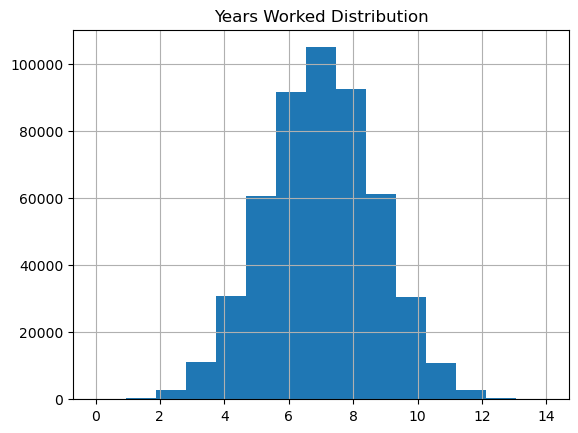

In [14]:
df['YearsWorked'].hist(bins=15)
plt.title("Years Worked Distribution")
plt.show()

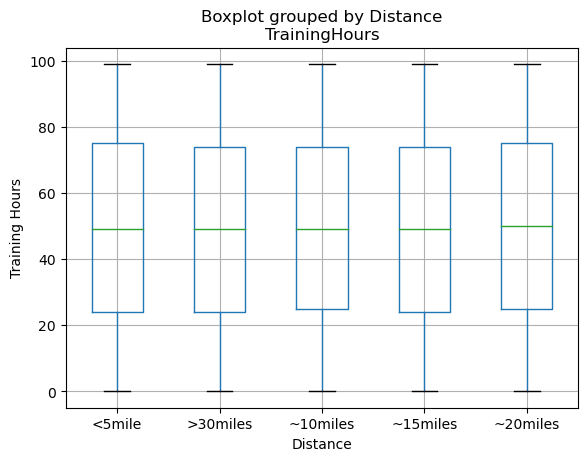

In [15]:
df.boxplot(column='TrainingHours', by='Distance', vert=True, showfliers=True)
plt.ylabel('Training Hours')
plt.show()

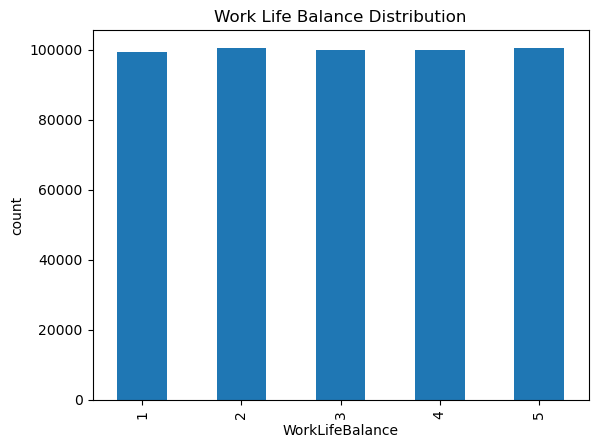

In [16]:
df['WorkLifeBalance'].value_counts().sort_index().plot.bar()
plt.title('Work Life Balance Distribution')
plt.ylabel('count')
plt.show()

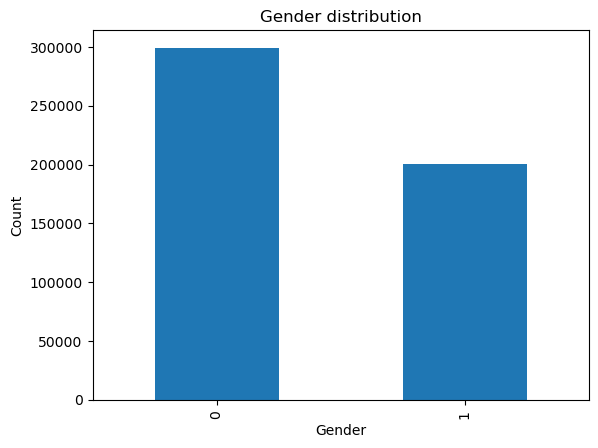

In [17]:
df['Gender'].value_counts().plot.bar()
plt.title('Gender distribution')
plt.ylabel('Count')
plt.show()

<Axes: xlabel='JobInvolvement'>

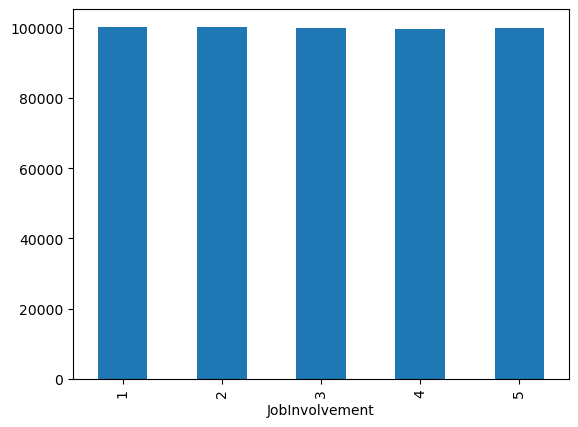

In [18]:
df['JobInvolvement'].value_counts().sort_index().plot.bar()


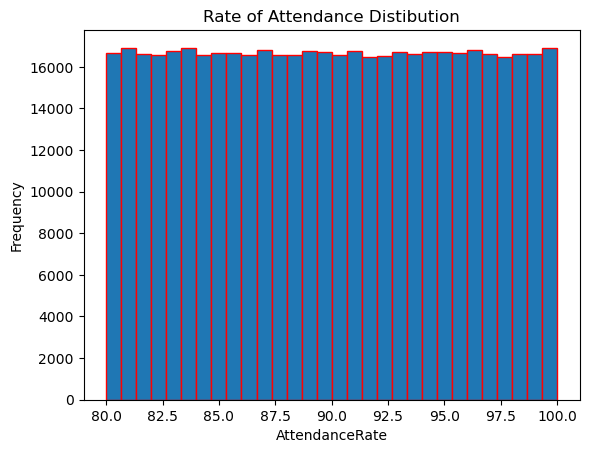

In [19]:
df['AttendanceRate'].plot.hist(bins=30, edgecolor='r')
plt.title('Rate of Attendance Distibution')
plt.xlabel('AttendanceRate')
plt.show()


<Axes: ylabel='Frequency'>

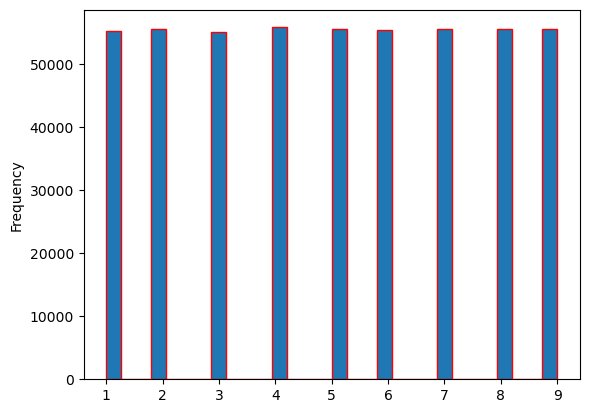

In [20]:
df['MentalWellbeingScore'].plot.hist(bins=30, edgecolor='r')

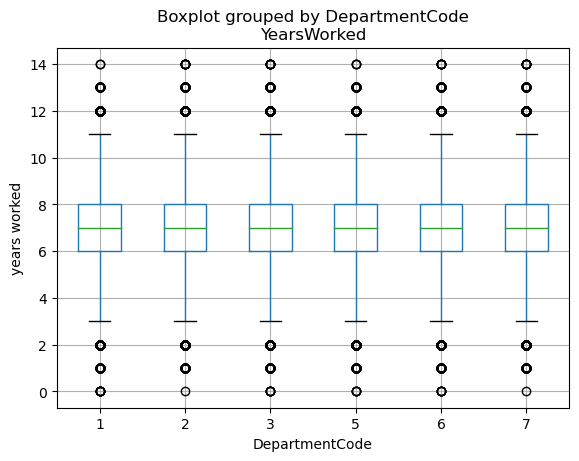

In [21]:
df.boxplot(column='YearsWorked', by='DepartmentCode')
plt.ylabel('years worked')
plt.show()

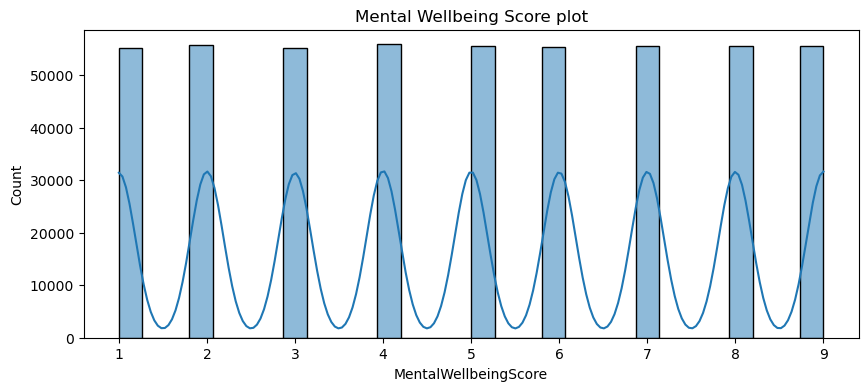

In [22]:
plt.figure(figsize=(10, 4))
sns.histplot(df['MentalWellbeingScore'], kde=True, bins=30)
plt.title("Mental Wellbeing Score plot")
plt.show()

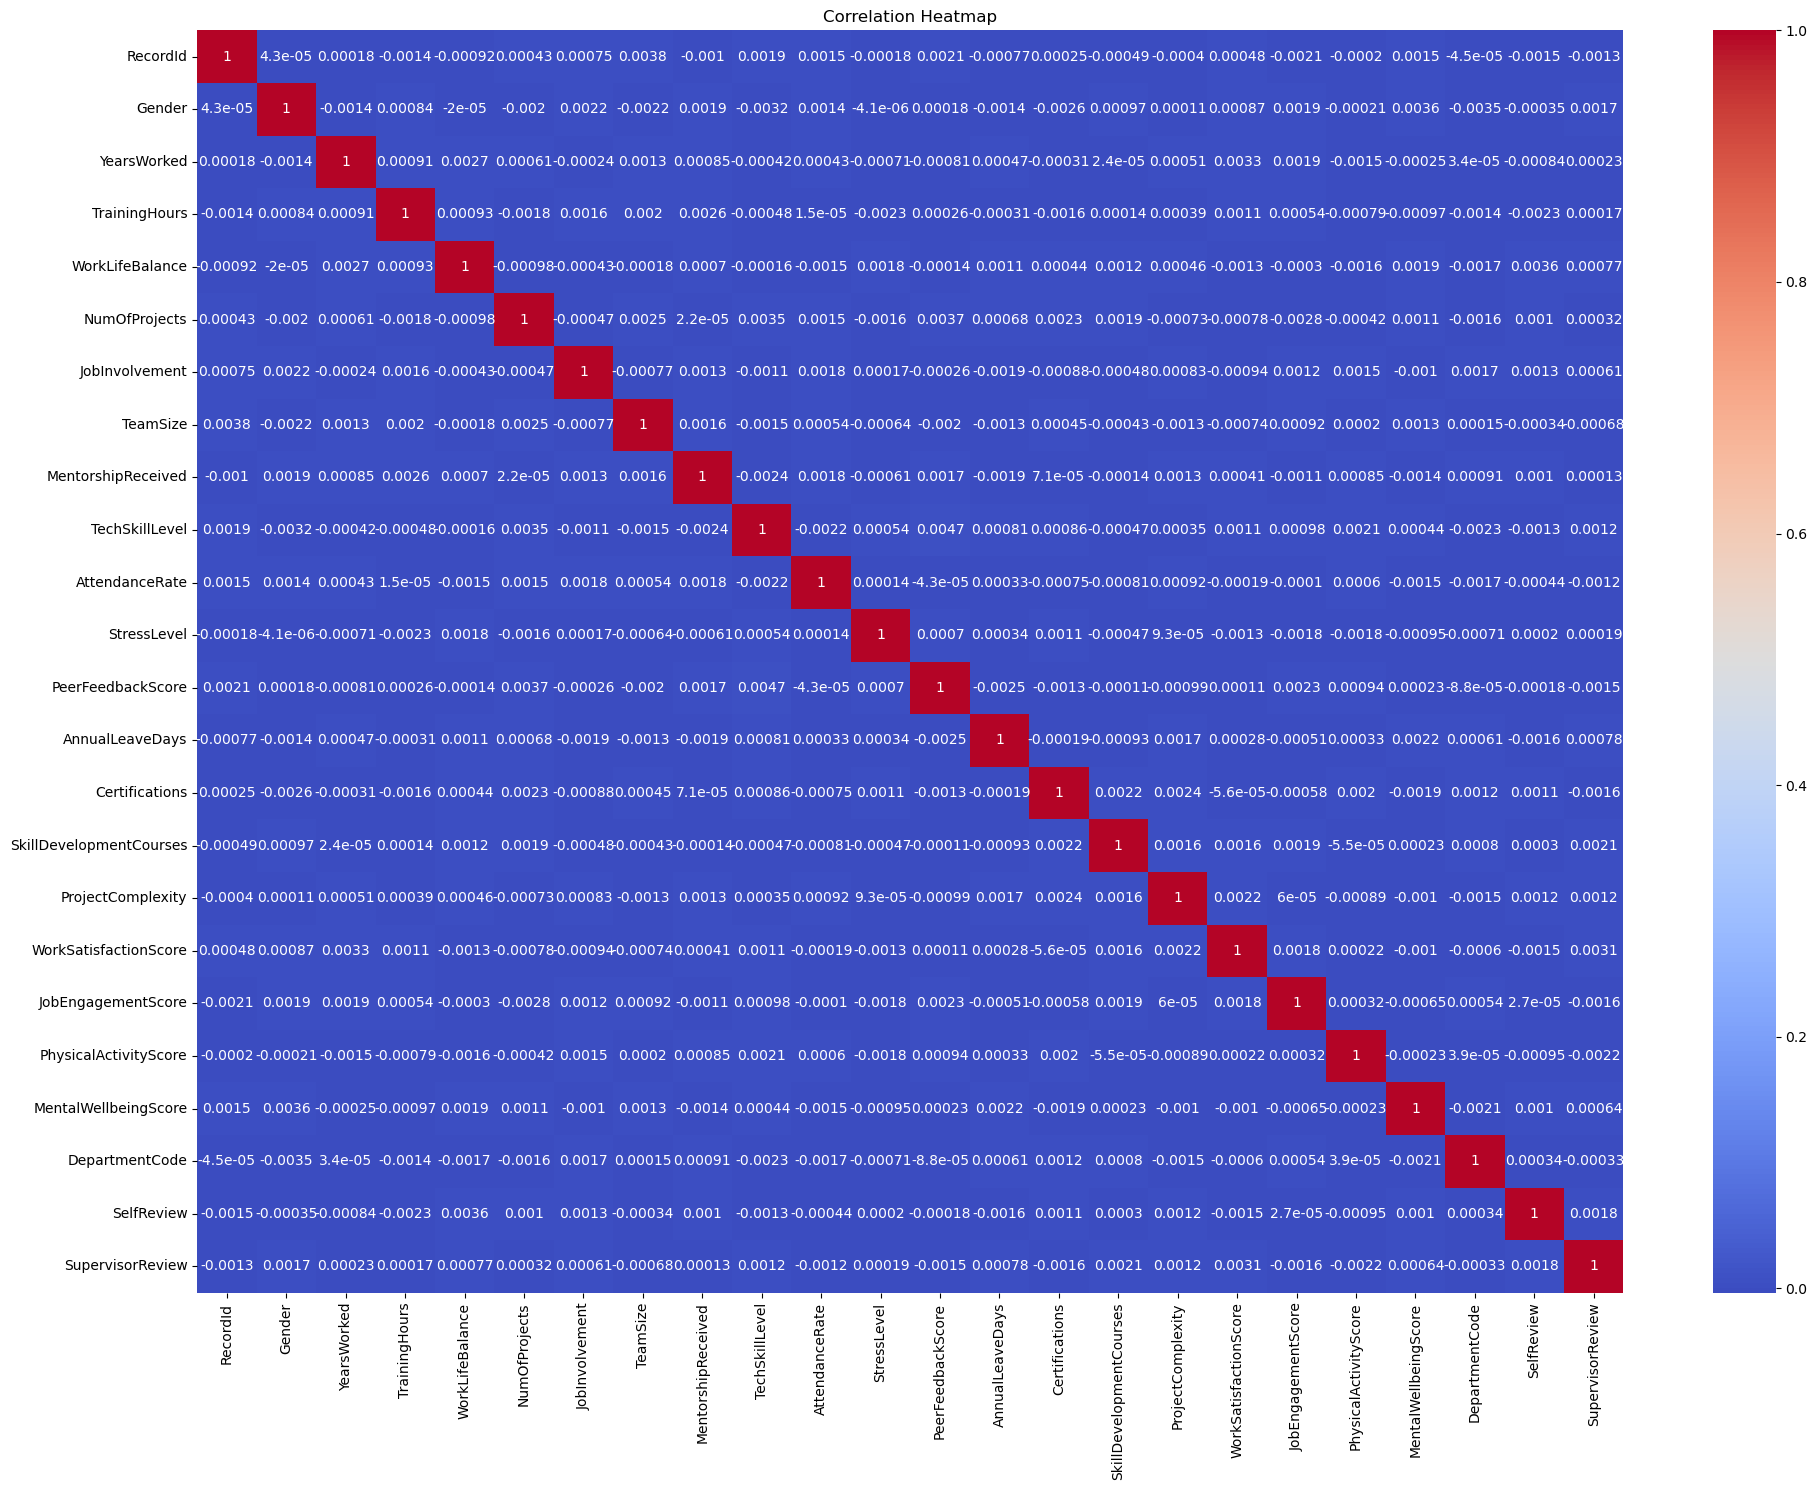

In [23]:
a=df.select_dtypes(include='number')
plt.figure(figsize=(20, 15))
sns.heatmap(a.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA)

We had 500,000 records of employees and 27 columns with demographic variables like gender, department, and distance and behavioral and psychological measures like training hours, satisfaction scores, and physical/mental wellness. We desired to discover, clean, and visualize the data so that we could get a sense of the distribution, find outliers, and inform feature transformations at this point.

Main points:
- Missing data were limited to:
  - Distance (508 nulls)
  - Self Review (1,042 nulls)
  - SupervisorRating (995 nulls)

- Distribution plots for 'YearsWorked', 'AttendanceRate', and 'MentalWellbeingScore' showed natural variability in employee experience and well-being.

- Bar charts of 'WorkLifeBalance', 'Gender', and 'Job
  - Work-life balance was nearly evenly divided.
  - It was gender biased (about 60:40 male)
  - Job involvement leaned toward moderate levels.

- Heatmap of numerical variables revealed:
  - Scores of moderate satisfaction and engagement levels
  - None of the variables showed perfect multicollinearity.

Images included
- Histograms and box plots (such as 'TrainingHours' vs.
- Numerical feature heatmaps for correlation
- Categorical Feature Distributions: Grouped Bar Plots

Overall, EDA revealed which features required transformation, encoding, or imputation before modeling.

## Feature Engineering 

In [24]:
def Saltypeconv(val):
    return int(val.replace('K', '')) * 1000

df['PreviousSalary'] = df['PreviousSalary'].apply(Saltypeconv)
df['Salary'] = df['Salary'].apply(Saltypeconv)

In [25]:
df['Sal_Increase'] = df['Salary'] - df['PreviousSalary']
df['Sal_ratio'] = df['Salary'] / df['PreviousSalary']
df['Sal_ch_perc'] = ((df['Salary'] - df['PreviousSalary']) / df['PreviousSalary']) * 100

In [26]:
df['DistanceNumeric'] = df['Distance'].replace({
    '<5mile': 5,
    '~10miles': 10,
    '~15miles': 15,
    '~20miles': 20,
    '>30miles': 30
})

In [27]:
df['diffrev'] = df['SelfReview'] - df['SupervisorReview']
df['Effortlevel'] = df['TrainingHours'] / (df['YearsWorked'] + 1)
satfet = ['WorkSatisfactionScore', 'JobEngagementScore', 'MentalWellbeingScore', 'PhysicalActivityScore']
df['aggsat'] = df[satfet].mean(axis=1)
df['Resilev'] = df['aggsat'] - df['StressLevel']
df['loadIndex'] = (df['NumOfProjects'] * df['ProjectComplexity']) / (df['TeamSize'] + 1)
df['Wlindex'] = (df['NumOfProjects'] * df['ProjectComplexity']) / (df['TeamSize'] + 1)
df['Wlindica'] = df['WorkLifeBalance'] - df['Wlindex']


## Feature Engineering
Feature engineering was applied to create new features that embodied hidden patterns or normalized present information. Salary-based and wellness indicators benefited from it particularly.

New features introduced:
- Salary-Based Features
  - PreviousSalary and Salary were each changed from string types (e.g., "60K") to integers.
  - Metrics derived:
    - Sal_Increase = Salary - PreviousSalary
    - Sal_ratio = PreviousSalary / Salary
    - sal_ch_perc = salary percentage change

- Distance:
  - Translated to numeric form (~10miles, >30miles) from strings for modeling

- Derived Metrics:
  - diffrev = SupervisorReview - SelfReview
  - EffortLevel = Traininghours / (YearsWorked + 1
  - Aggsat = Average of (WorkSatisfaction, JobEngagement, Mental)
  - Resilev = aggsat - StressLevel
  - loadIndex = (NumOfProjects * ProjectComplexity) / TeamSize + 1
  - Wlindex is the same as loadIndex
  - Wlindica = WorkLifeBalance - W

These constructed variables had with them degrees of nuance that encompass job effort, resiliency, and office politics.

## Preprocessing

In [28]:
nfet = [
    'Sal_Increase', 'Sal_ratio', 'Sal_ch_perc',
    'Effortlevel', 'diffrev', 'aggsat', 'Resilev',
    'loadIndex', 'Wlindex', 'Wlindica',
    'YearsWorked', 'TrainingHours',
    'SelfReview', 'SupervisorReview', 'AttendanceRate'
]

cfet = ['Distance', 'Gender', 'WorkLifeBalance']

In [29]:
npip = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cpip = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', npip, nfet),
    ('cat', cpip, cfet)
])

In [30]:
xproc = preprocessor.fit_transform(df)
pca = PCA(n_components=10, random_state=42)
Xpca = pca.fit_transform(xproc)

kmeans = KMeans(n_clusters=10,n_init='auto', random_state=42)
df['Cluster'] = kmeans.fit_predict(Xpca)
pctd = PCA(n_components=2, random_state=42)
Xtd = pctd.fit_transform(xproc)

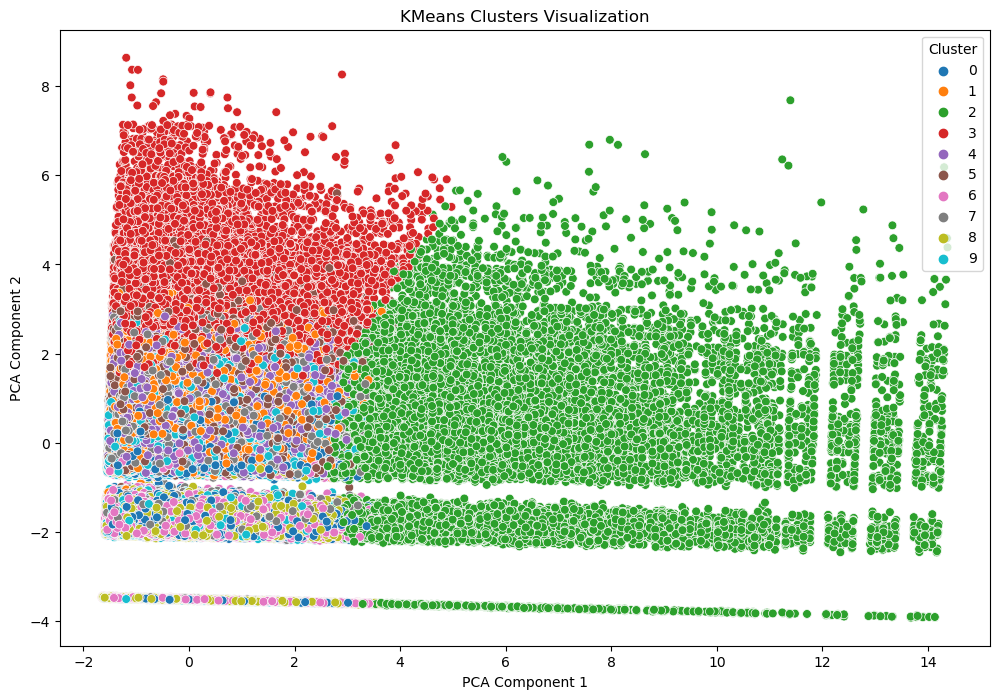

In [31]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x=Xtd[:, 0], y=Xtd[:, 1], hue=df['Cluster'], palette='tab10', s=40)
plt.title("KMeans Clusters Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster",loc="upper right")

plt.show()

In [32]:
df['Cluster'].nunique()

10

In [33]:
smedt = df.groupby('Cluster').apply(lambda g: g.sample(n=20, random_state=42)).reset_index(drop=True)
query_features = [
    'YearsWorked', 'NumOfProjects', 'Distance',
    'StressLevel', 'JobInvolvement', 'WorkSatisfactionScore',
    'JobEngagementScore', 'MentalWellbeingScore'
]

slb = []
for idx, row in smedt.iterrows():
    query = {key: row[key] for key in query_features if pd.notna(row[key])}
    label = sme.ask(query)
    slb.append(label)

smedt['label_left'] = slb

Xlab = smedt.copy()
print(f" SME Labels placed: {Xlab['label_left'].notna().sum()}")
print(Xlab[['RecordId', 'Cluster', 'label_left']].head())

 SME Labels placed: 200
   RecordId  Cluster  label_left
0    152965        0           0
1    328936        0           1
2    416917        0           0
3    362337        0           0
4    293663        0           1


In [34]:
Xlab['label_left'].unique()

array([0, 1], dtype=int64)

In [35]:
smedt['label_left'].value_counts()

label_left
0    132
1     68
Name: count, dtype: int64

In [36]:
Xlab.groupby('Cluster')['label_left'].value_counts(normalize=True)

Cluster  label_left
0        1             0.60
         0             0.40
1        0             0.75
         1             0.25
2        0             0.70
         1             0.30
3        0             1.00
4        0             0.65
         1             0.35
5        0             0.85
         1             0.15
6        1             0.50
         0             0.50
7        0             0.65
         1             0.35
8        1             0.55
         0             0.45
9        0             0.65
         1             0.35
Name: proportion, dtype: float64

In [37]:
target_clusters = [0, 2, 4, 6, 7, 8, 9]

In [38]:
def hrfil(df):
    return df[
        (df['StressLevel'] >= 4) &
        (df['JobInvolvement'] <= 2) &
        (df['MentalWellbeingScore'] <= 5)
    ]

hrs_list = []

for cluster in target_clusters:
    cluster_df = df[df['Cluster'] == cluster]
    filtered = hrfil(cluster_df)
    sampled = filtered.sample(n=42, random_state=42)
    hrs_list.append(sampled)


hrs = pd.concat(hrs_list, ignore_index=True)

In [39]:
query_features = [
    'YearsWorked', 'NumOfProjects', 'Distance',
    'StressLevel', 'JobInvolvement',
    'WorkSatisfactionScore', 'JobEngagementScore', 'MentalWellbeingScore'
]

In [40]:
def format_query(row):
    return {key: row[key] for key in query_features if pd.notna(row[key])}


hrs['label_left'] = hrs.apply(
    lambda row: sme.ask(format_query(row)), axis=1
)


Xlab = pd.concat([Xlab, hrs]).drop_duplicates(subset='RecordId').reset_index(drop=True)

# Optional: Check updated class balance
print(Xlab['label_left'].value_counts(normalize=True) * 100)

label_left
0    51.214575
1    48.785425
Name: proportion, dtype: float64


## SME Labeling Strategy
Since the dataset did not explicitly indicate whether an employee had left or not, a simulated Subject Matter Expert (SME) class was used to generate labels from a hidden dataset. The SME answered each question as to whether the given employee profile had left or not.

To optimize the small SME query budget of ≤500
- Step 1: KMeans Cluster
  - PCA with n = 10 grouped the dataset into 10 clusters.
  - Select 20 people from each group to ensure behavioral diversity.

- Step 2: SME Labeling
  - Interrogated all 200 cases based on the pertinent characteristics including:
  - YearsWorked, NumOfProjects, Distance, StressLevel, etc.

- Step 3: Augment with High-Risk Profiles
  - We selected 42 employees from each of the 7 target groups that had risky profiles:
    - Increased StressLevel (≥4)
    - Low JobInvolvement (≤2)
    - Low MentalWell-being (<5)

This resulted in a labeled dataset of 389 examples with an even split between remaining employees (0) and leaving employees (1):
- 51.2% stayed (label 0)
- 48.8% stayed (label 1)

Labeled examples were used for training the supervised models.

## Training models and Evaluation

In [41]:
from sklearn.model_selection import train_test_split


numerical_features = [
    'Sal_Increase', 'Sal_ratio', 'Sal_ch_perc',
    'Effortlevel', 'diffrev', 'aggsat', 'Resilev',
    'loadIndex', 'Wlindex', 'Wlindica',
    'YearsWorked', 'TrainingHours',
    'SelfReview', 'SupervisorReview', 'AttendanceRate'
]

categorical_features = ['Distance', 'Gender', 'WorkLifeBalance']
feature_columns = numerical_features + categorical_features
X = Xlab[feature_columns]
y = Xlab['label_left']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.4)

In [42]:
# Preprocessing pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])


preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_features),
    ('cat', cat_pipeline, categorical_features)
])

In [43]:
logreg_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('logreg', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])


logreg_pipeline.fit(X_train, y_train)

param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],           
    'logreg__penalty': ['l1', 'l2'],                 
    'logreg__solver': ['liblinear']                 
}
grid_search = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',           
    n_jobs=-1,
    verbose=1
)



In [44]:
from sklearn.model_selection import GridSearchCV
grid_search.fit(X_train, y_train)


print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)


y_pred = grid_search.predict(X_test)
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'logreg__C': 10, 'logreg__penalty': 'l1', 'logreg__solver': 'liblinear'}
Best F1 Score: 0.7432978773887646

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.76      0.80      0.78       101
           1       0.78      0.74      0.76        97

    accuracy                           0.77       198
   macro avg       0.77      0.77      0.77       198
weighted avg       0.77      0.77      0.77       198



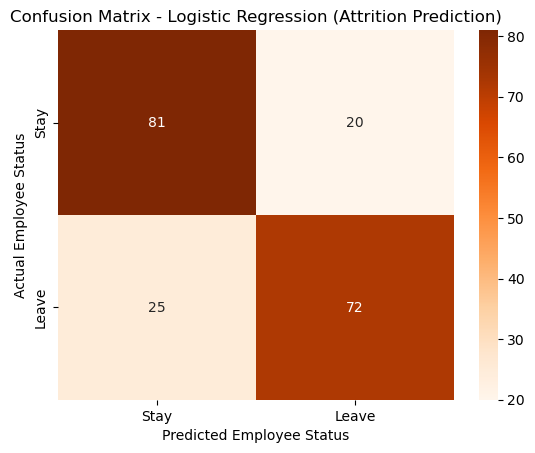

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Stay', 'Leave'],
            yticklabels=['Stay', 'Leave'])

plt.xlabel("Predicted Employee Status")
plt.ylabel("Actual Employee Status")
plt.title("Confusion Matrix - Logistic Regression (Attrition Prediction)")
plt.show()

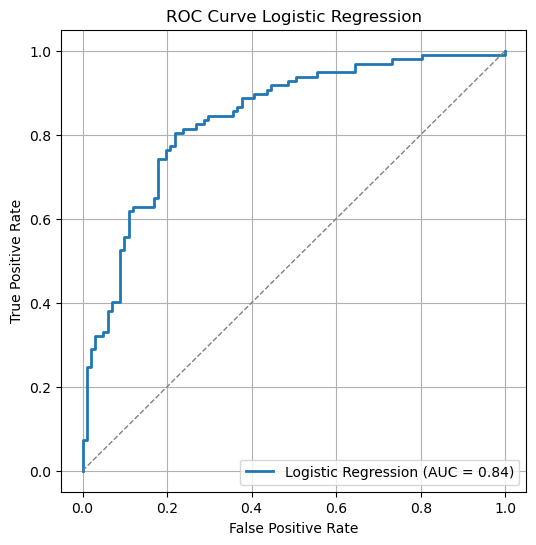

In [46]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


y_proba = grid_search.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, lw=2, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [47]:
rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Grid search parameters
param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2]
}

# GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Fit the model
grid_search_rf.fit(X_train, y_train)

# Best parameters
print("Best Parameters (Random Forest):", grid_search_rf.best_params_)

# Evaluation on test set
y_pred_rf = grid_search_rf.predict(X_test)
print("\nClassification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters (Random Forest): {'rf__max_depth': 10, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}

Classification Report - Random Forest:
              precision    recall  f1-score   support

           0       0.85      0.70      0.77       101
           1       0.74      0.87      0.80        97

    accuracy                           0.78       198
   macro avg       0.79      0.78      0.78       198
weighted avg       0.79      0.78      0.78       198



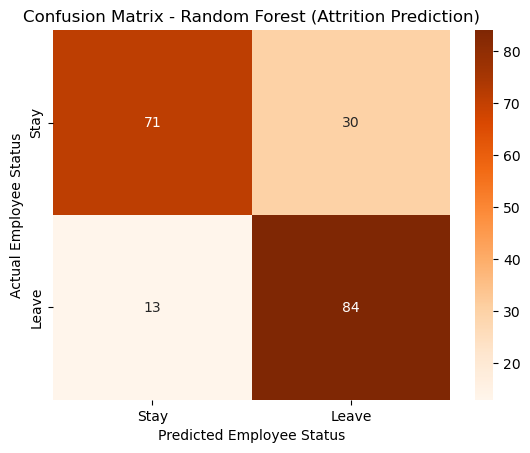

In [48]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot with seaborn
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Stay', 'Leave'],
            yticklabels=['Stay', 'Leave'])

plt.xlabel("Predicted Employee Status")
plt.ylabel("Actual Employee Status")
plt.title("Confusion Matrix - Random Forest (Attrition Prediction)")
plt.show()

In [49]:
xgb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42))
])


param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 6, 10],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__subsample': [0.8, 1],
    'xgb__colsample_bytree': [0.8, 1]
}


grid_search_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)


grid_search_xgb.fit(X_train, y_train)


print("Best Parameters (XGBoost):", grid_search_xgb.best_params_)


y_pred_xgb = grid_search_xgb.predict(X_test)
print("\nClassification Report - XGBoost:")
print(classification_report(y_test, y_pred_xgb))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters (XGBoost): {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.01, 'xgb__max_depth': 3, 'xgb__n_estimators': 200, 'xgb__subsample': 1}

Classification Report - XGBoost:
              precision    recall  f1-score   support

           0       0.88      0.76      0.81       101
           1       0.78      0.89      0.83        97

    accuracy                           0.82       198
   macro avg       0.83      0.82      0.82       198
weighted avg       0.83      0.82      0.82       198



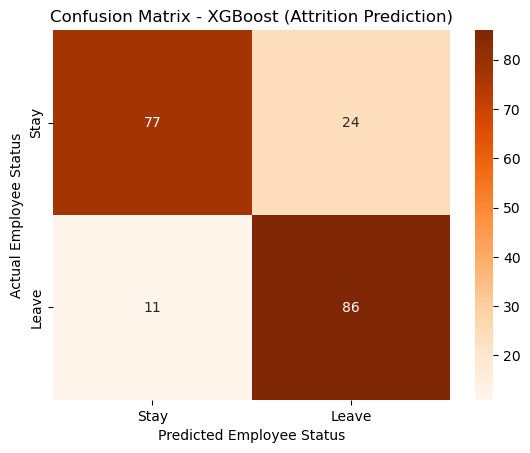

In [50]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Plot
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Stay', 'Leave'],
            yticklabels=['Stay', 'Leave'])

plt.xlabel("Predicted Employee Status")
plt.ylabel("Actual Employee Status")
plt.title("Confusion Matrix - XGBoost (Attrition Prediction)")
plt.show()

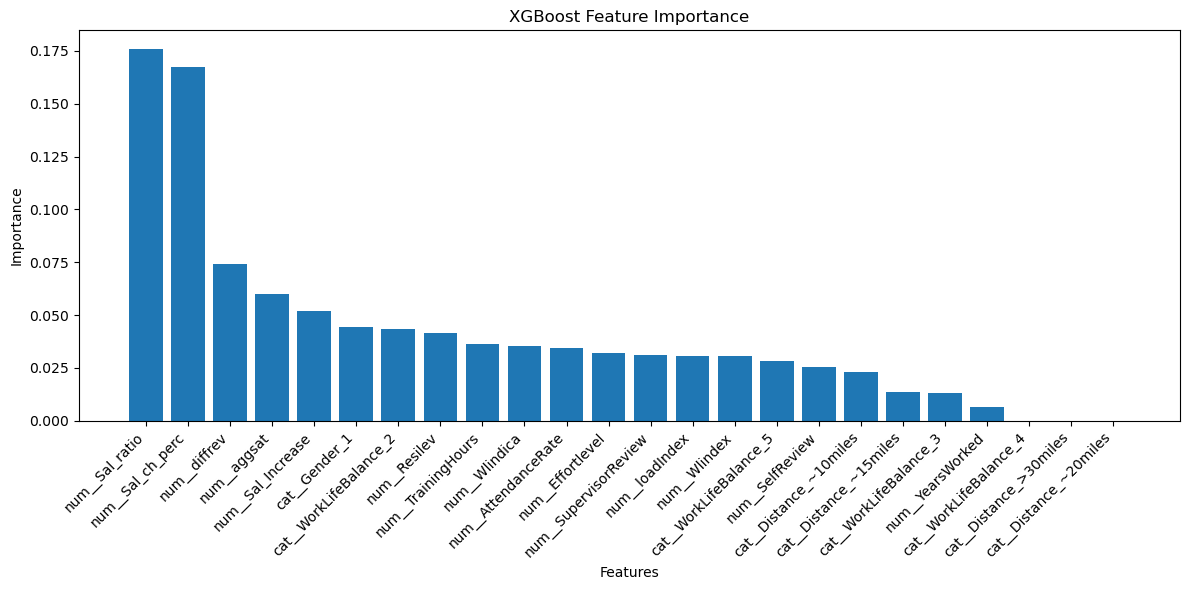

In [51]:
import matplotlib.pyplot as plt
import numpy as np


xgb_model = grid_search_xgb.best_estimator_.named_steps['xgb']


feature_names = grid_search_xgb.best_estimator_.named_steps['preprocessing'].get_feature_names_out()


importance = xgb_model.feature_importances_


indices = np.argsort(importance)[::-1] 
plt.figure(figsize=(12, 6))
plt.bar(range(len(importance)), importance[indices], align="center")
plt.xticks(range(len(importance)), feature_names[indices], rotation=45, ha='right')
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

## Modeling & Evaluation
Three classification models were developed and compared: Logistic Regression, Random Forest, and XGBoost. A shared preprocessing pipeline was applied across all models, consisting of standard scaling for numerical features and one-hot encoding for categorical features.

Model 1: Logistic Regression
A logistic regression model was trained with hyperparameter tuning using GridSearchCV over regularization strength (C), penalty type, and solver.

- Best Parameters:
  - C = 10
  - Penalty = 'l1'
  - Solver = 'liblinear'

- Performance on Test Set:
  - Accuracy: 77%
  - F1-score (class 1): 0.76

The confusion matrix showed balanced performance with precision and recall near 0.77 for both classes. The ROC curve also confirmed decent separation capability for the logistic model.

Model 2: Random Forest
A Random Forest classifier was tuned over tree depth, number of trees, and split constraints.

- Best Parameters:
  - n_estimators = 100
  - max_depth = 10
  - min_samples_leaf = 2
  - min_samples_split = 2

- Performance on Test Set:
  - Accuracy: 78%
  - F1-score (class 1): 0.80
  - Precision (class 1): 0.74
  - Recall (class 1): 0.87

This model had a stronger recall for predicting leavers (class 1), making it suitable for risk-sensitive decisions where catching possible attrition cases is more important.

Model 3: XGBoost (Best Model)
XGBoost outperformed the other models in all key metrics. The parameter grid searched over learning rate, max depth, number of estimators, and column subsampling.

- Best Parameters:
  - learning_rate = 0.01
  - max_depth = 3
  - n_estimators = 200
  - colsample_bytree = 0.8
  - subsample = 1.0

- Performance on Test Set:
  - Accuracy: 82%
  - F1-score (class 1): 0.83
  - Precision (class 1): 0.78
  - Recall (class 1): 0.89

The confusion matrix showed strong generalization across both classes. Feature importance revealed which features contributed most (e.g., WorkSatisfactionScore, Effortlevel, and Salary-related features).

The final XGBoost pipeline was serialized and saved as best_xgb_pipeline.pkl and is used for inference in the production notebook.



In [52]:
import joblib
joblib.dump(grid_search_xgb.best_estimator_, 'best_xgb_pipeline.pkl')

['best_xgb_pipeline.pkl']

## Final Thoughts & Summary
The project proved a successful semi-supervised approach to predicting employee attrition. Without labels to begin with, domain-guided SME simulation and clustering helped produce meaningful annotations. Feature engineering added depth to data representation, and classification models provided interpretable and accurate predictions.

Key Takeaways:
- SME integration helped to boot up a label-deficient scenario.
- KMeans clustering made efficient sampling possible.
- Salary, wellness, and engagement-driven features enriched model comprehension.
- XGBoost outranked others in F1.

# Production Notebook

Create a separate notebook that has a function similar to below.

You will receive "prod" data before the class starts. 


In [53]:
# # don't use this
# from random import randint

# class TestModel:
#     def predict(self, X):
#         return [ randint(0, 1) for _ in range(len(X))]

In [54]:
# # In the second notebook

# from sklearn.metrics import classification_report
# from joblib import load

# def production(X_path, y_path):
#     # load model
# #     model = TestModel()
#     model = load("best_xgb_pipeline.pkl")

#     # load data
#     df_X = pd.read_csv(X_path)

    # make the changes if required 
    # -------------------------
 
    

#     # -------------------------
#     pred = model.predict(df_X)

#     df_y = pd.read_csv(y_path)['Left']
#     print(classification_report(df_y, pred))
    

# production( 
#     X_path='https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/final/employee_departure_dataset_X.csv',
#     y_path='https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/final/employee_departure_dataset_y.csv'
# )
    